In [1]:
import vesuvius
from vesuvius import Volume
import matplotlib.pyplot as plt
segment_id = 20230827161847
segment = Volume(segment_id, normalize=True)

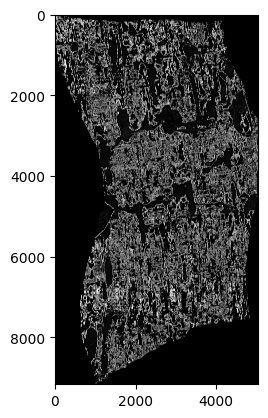

In [2]:
plt.imshow(segment[0,:,:], cmap='grey')

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


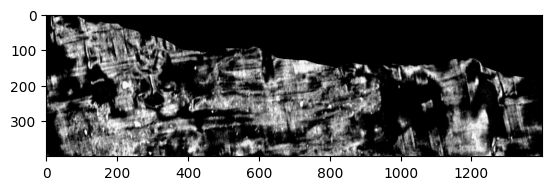

In [3]:
plt.imshow(segment[28,0:400,0:1400], cmap='gray')
print(segment[28,200:232,1000:1032])

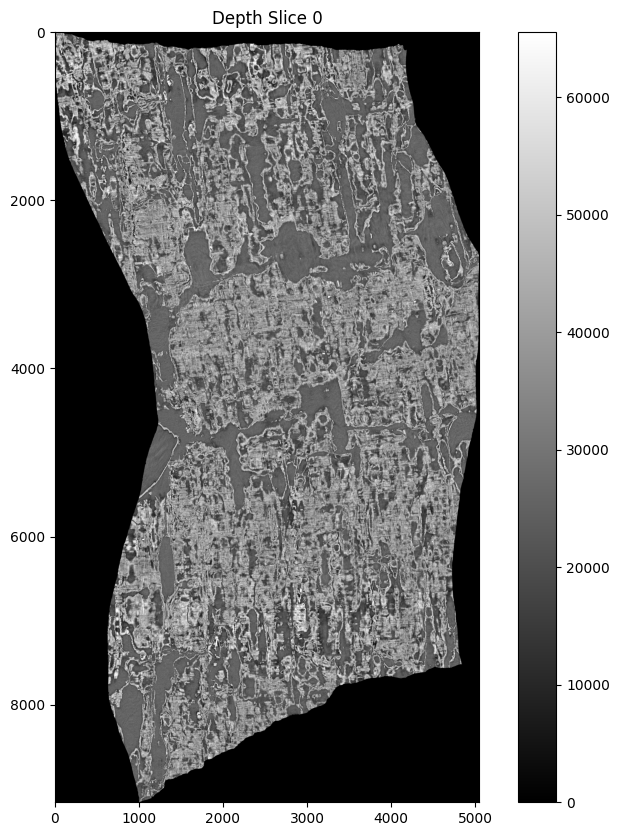

In [4]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

# Configuration
zarr_path = "/media/jeff/Seagate/vesuvius-3dstreamer/20230827161847_singlethreaded.zarr"  # Update with your Zarr path
start_level = 0
end_level = 21

# Load the Zarr volume
volume = zarr.open(zarr_path, mode='r')

# Assemble the image by iterating through the depth levels
assembled_image = []
for z in range(start_level, end_level):
    # Extract the chunk at the current depth
    chunk = volume[z, :, :]
    assembled_image.append(chunk)

# Stack the depth slices into a 3D array
assembled_image = np.stack(assembled_image, axis=0)

# Display the assembled image
# For visualization, we can display a single depth slice or a projection
plt.figure(figsize=(10, 10))
plt.imshow(assembled_image[0], cmap='grey')  # Display the first depth slice
plt.title(f"Depth Slice {start_level}")
plt.colorbar()
plt.show()

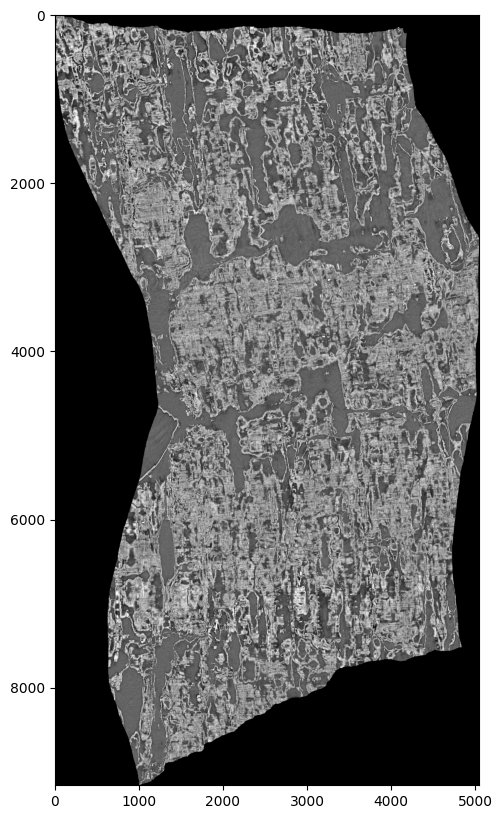

In [5]:
plt.figure(figsize=(10, 10))
plt.imshow(assembled_image[0], cmap='grey')

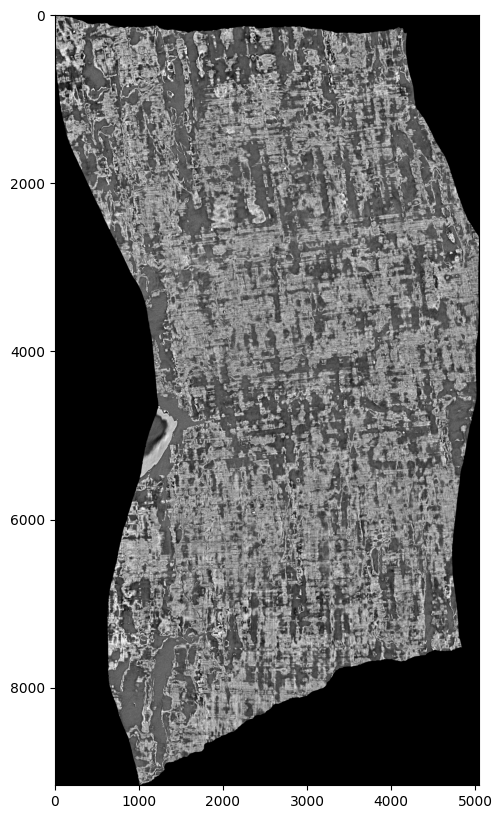

In [6]:
plt.figure(figsize=(10, 10))
plt.imshow(assembled_image[19], cmap='grey')

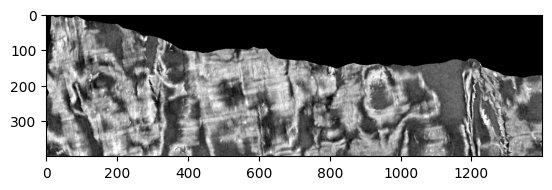

In [7]:
plt.imshow(assembled_image[0, 0:400, 0:1400]/65535, cmap='gray')

0.0
1.0


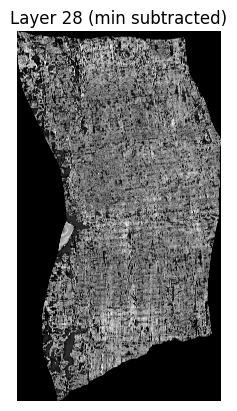

In [8]:
import tifffile

tif_path = "/media/jeff/Seagate/phalanx/data/scroll1/fragments/20230827161847/layers/28.tif"
tif_image = tifffile.imread(tif_path)/65535
print(tif_image.min())
print(tif_image.max())

# subtract 0.25, clip to 0 where necessary

tif_image_adj = tif_image - 0.265
tif_image_adj = tif_image_adj.clip(min=0)

plt.imshow(tif_image_adj, cmap='gray')
plt.title("Layer 28 (min subtracted)")
plt.axis('off')
plt.show()

